# MATH 440 — Final Project
## Model Selection from Curated Datasets

**Name:** Eren Onat 
**Date submitted:** [5/4/26]  
**Dataset:** [DS 14 Modeling Dungenous crab cohort biomass]


---
## Imports and Global Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Use Numpy's modern RNG (for the bootstrap in Step 5)
rng = np.random.default_rng(2026)

# Golden-ratio figure dimensions (inches)
golden_ratio = (1 + 5**0.5) / 2
FIG_HEIGHT   = 5
FIG_WIDTH    = FIG_HEIGHT * golden_ratio

# Specify font size and figure quality for all figures
plt.rcParams.update({'font.size': 11, 'figure.dpi': 300})

## Data and Configuration
Define your data file path and any fixed parameter values here.

In [2]:
# Load your data
DATA_FILE = 'DS14.csv' # update to your assigned dataset

# Fixed parameters from scenario card.
THETA_FIXED = 0.7
C_FIXED     = None

# Load the dataset using pandas
df = pd.read_csv(DATA_FILE)
print("Column names: ", df.columns.tolist()) # shows the actual column names
print(df.head()) # quick sanity check

t_data = df.iloc[:, 0].to_numpy(dtype=float)   # column 0 = time
y_data = df.iloc[:, 1].to_numpy(dtype=float)   # column 1 = QOI
n_obs  = len(y_data)
N0 = y_data[0]   # initial observed value


print(f'Dataset: {DATA_FILE}')
print(f'Observations: n = {n_obs}')
print(f'Time range: {t_data[0]:.4g} to {t_data[-1]:.4g}')
print(f'QOI range: {y_data.min():.4g} to {y_data.max():.4g}')
print(f'Initial value: N(0) ≈ {y_data[0]:.4g}')

Column names:  ['year', 'cohort_biomass_mt']
   year  cohort_biomass_mt
0     0              138.0
1     1              246.0
2     2              528.0
3     3              940.0
4     4              913.0
Dataset: DS14.csv
Observations: n = 55
Time range: 0 to 54
QOI range: 138 to 1.194e+04
Initial value: N(0) ≈ 138


---
## Step 2. Analyze (Raw data plot)

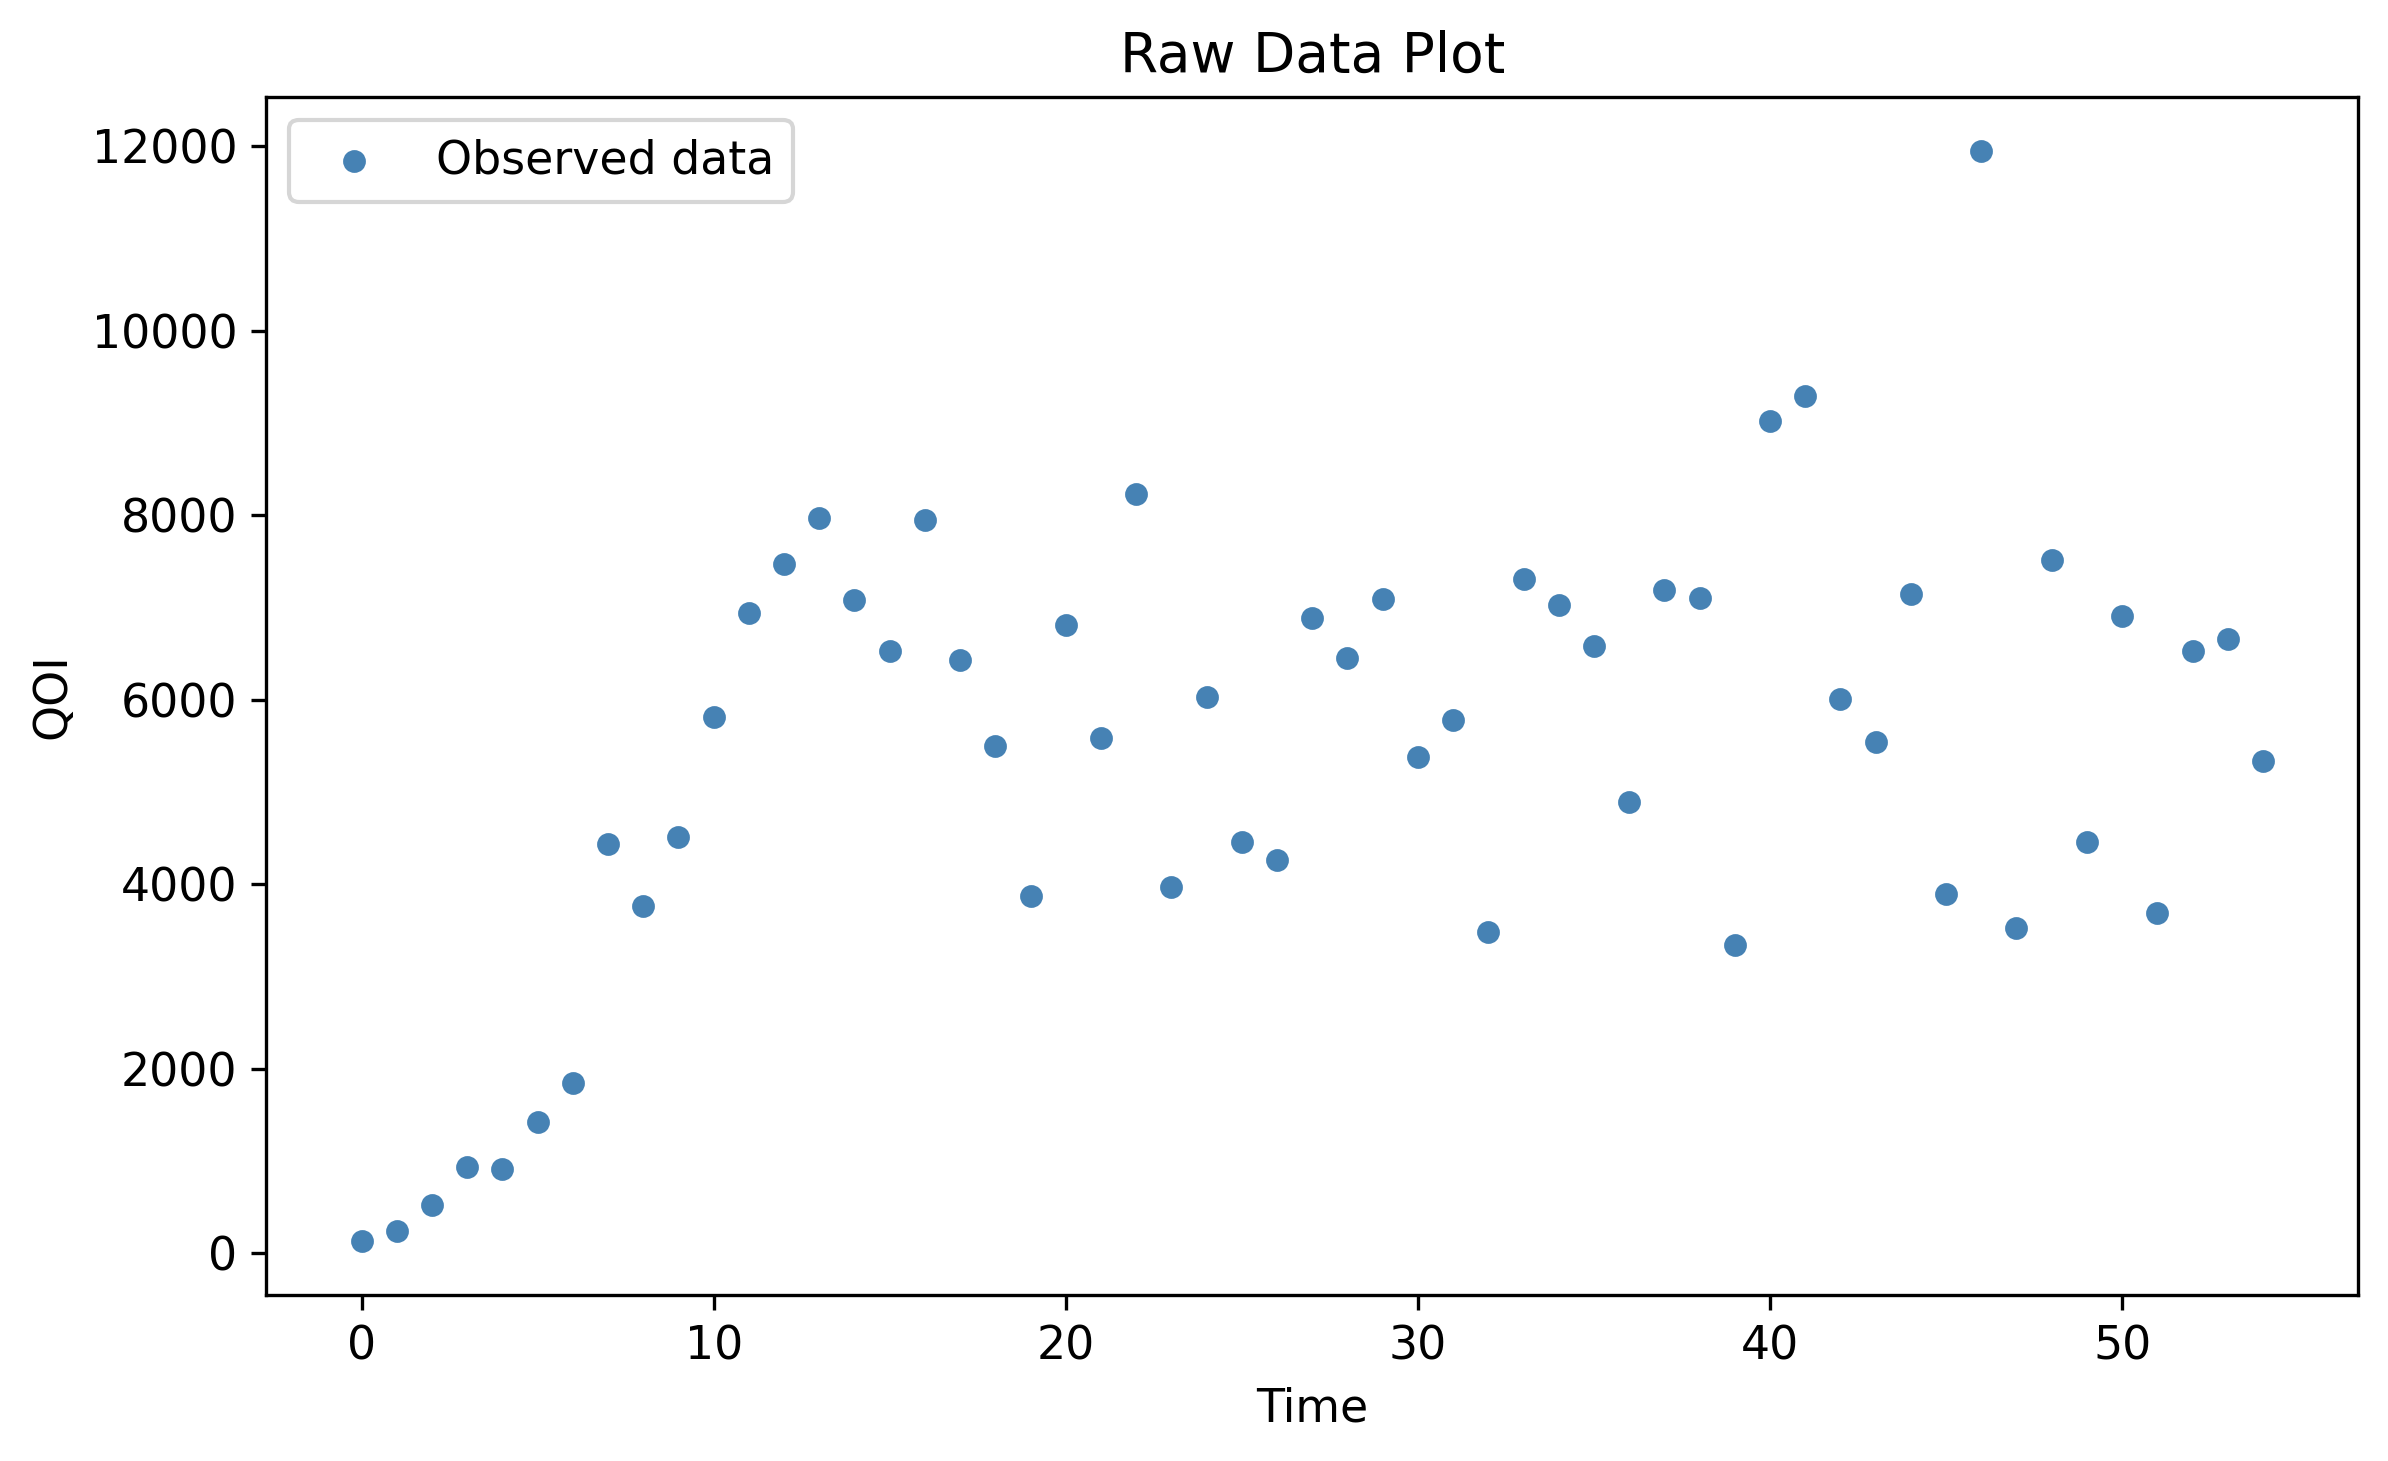

In [3]:
# Raw Data Plot

plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
plt.scatter(t_data, y_data, s=20, color='steelblue', label='Observed data')
plt.xlabel('Time')   
plt.ylabel('QOI')             
plt.title('Raw Data Plot')  
plt.legend()
plt.tight_layout()
plt.savefig('raw_data.png')
plt.show()

### Model functions

In [4]:

# Model 1: Discrete Logistic
# N_{t+1} = N_t(1 + r(1 - N_t/K))
def model1_discrete_logistic(t, r, K):
    N = np.zeros(len(t))
    N[0] = N0
    for i in range(len(t) - 1):
        N[i+1] = N[i] * (1 + r * (1 - N[i] / K))
    return N

# Model 2: Smith-Slatkin
# N_{t+1} = (N_t * e^r) / (1 + (e^r - 1)*N_t/K)
def model2_smith_slatkin(t, r, K):
    N = np.zeros(len(t))
    N[0] = N0
    exp_r = np.exp(r)
    for i in range(len(t) - 1):
        N[i+1] = (N[i] * exp_r) / (1 + (exp_r - 1) * N[i] / K)
    return N

# Model 3: Beverton-Holt
# N_{t+1} = (lambda * N_t) / (1 + a*N_t)
def model3_beverton_holt(t, lam, a):
    N = np.zeros(len(t))
    N[0] = N0
    for i in range(len(t) - 1):
        N[i+1] = (lam * N[i]) / (1 + a * N[i])
    return N

# Model 4: Ricker
# N_{t+1} = N_t * exp(r(1 - N_t/K))
def model4_ricker(t, r, K):
    N = np.zeros(len(t))
    N[0] = N0
    for i in range(len(t) - 1):
        N[i+1] = N[i] * np.exp(r * (1 - N[i] / K))
    return N

# Model 5: Theta-Ricker (with THETA_FIXED = 0.7)
# N_{t+1} = N_t * exp(r(1 - (N_t/K)^theta))
def model5_theta_ricker(t, r, K):
    N = np.zeros(len(t))
    N[0] = N0
    for i in range(len(t) - 1):
        N[i+1] = N[i] * np.exp(r * (1 - (N[i] / K)**THETA_FIXED))
    return N


In [5]:
# Fit all 5 models using curve_fit
# Improved initial guesses and bounds for better fit

ymax = np.max(y_data)
ymean = np.mean(y_data)

# For better fitting to oscillating data, use mean/median as equilibrium estimate
# rather than max which can be an outlier
K_guess = ymean * 1.3  # equilibrium estimate based on mean biomass

# Model 1: Discrete Logistic
p0_1 = [0.15, K_guess]
bounds_1 = ([0.01, ymean * 0.8], [0.5, ymax * 1.5])
params_1, cov_1 = curve_fit(model1_discrete_logistic, t_data, y_data, p0=p0_1, bounds=bounds_1, maxfev=10000)
ypred_1 = model1_discrete_logistic(t_data, *params_1)
perr_1 = np.sqrt(np.diag(cov_1))

# Model 2: Smith-Slatkin
p0_2 = [0.15, K_guess]
bounds_2 = ([0.01, ymean * 0.8], [0.5, ymax * 1.5])
params_2, cov_2 = curve_fit(model2_smith_slatkin, t_data, y_data, p0=p0_2, bounds=bounds_2, maxfev=10000)
ypred_2 = model2_smith_slatkin(t_data, *params_2)
perr_2 = np.sqrt(np.diag(cov_2))

# Model 3: Beverton-Holt
p0_3 = [1.3, 0.1 / ymean]
bounds_3 = ([1.01, 1e-5], [3, 1e-3])
params_3, cov_3 = curve_fit(model3_beverton_holt, t_data, y_data, p0=p0_3, bounds=bounds_3, maxfev=10000)
ypred_3 = model3_beverton_holt(t_data, *params_3)
perr_3 = np.sqrt(np.diag(cov_3))

# Model 4: Ricker
p0_4 = [0.15, K_guess]
bounds_4 = ([0.01, ymean * 0.8], [0.5, ymax * 1.5])
params_4, cov_4 = curve_fit(model4_ricker, t_data, y_data, p0=p0_4, bounds=bounds_4, maxfev=10000)
ypred_4 = model4_ricker(t_data, *params_4)
perr_4 = np.sqrt(np.diag(cov_4))

# Model 5: Theta-Ricker
p0_5 = [0.15, K_guess]
bounds_5 = ([0.01, ymean * 0.8], [0.5, ymax * 1.5])
params_5, cov_5 = curve_fit(model5_theta_ricker, t_data, y_data, p0=p0_5, bounds=bounds_5, maxfev=10000)
ypred_5 = model5_theta_ricker(t_data, *params_5)
perr_5 = np.sqrt(np.diag(cov_5))

print('Model Fits Summary (Improved):')
print('='*60)
print(f'Mean biomass: {ymean:.0f} mt')
print(f'Max biomass:  {ymax:.0f} mt')
print()
print(f'Model 1: Discrete Logistic')
print(f'  r = {params_1[0]:.5g} ± {perr_1[0]:.5g}')
print(f'  K = {params_1[1]:.5g} ± {perr_1[1]:.5g}')
print()
print(f'Model 2: Smith-Slatkin')
print(f'  r = {params_2[0]:.5g} ± {perr_2[0]:.5g}')
print(f'  K = {params_2[1]:.5g} ± {perr_2[1]:.5g}')
print()
print(f'Model 3: Beverton-Holt')
print(f'  λ = {params_3[0]:.5g} ± {perr_3[0]:.5g}')
print(f'  a = {params_3[1]:.5g} ± {perr_3[1]:.5g}')
print()
print(f'Model 4: Ricker')
print(f'  r = {params_4[0]:.5g} ± {perr_4[0]:.5g}')
print(f'  K = {params_4[1]:.5g} ± {perr_4[1]:.5g}')
print()
print(f'Model 5: Theta-Ricker (θ = {THETA_FIXED})')
print(f'  r = {params_5[0]:.5g} ± {perr_5[0]:.5g}')
print(f'  K = {params_5[1]:.5g} ± {perr_5[1]:.5g}')


Model Fits Summary (Improved):
Mean biomass: 5447 mt
Max biomass:  11940 mt

Model 1: Discrete Logistic
  r = 0.5 ± 0.058271
  K = 6303.3 ± 269.54

Model 2: Smith-Slatkin
  r = 0.5 ± 0.058381
  K = 6308.7 ± 256.63

Model 3: Beverton-Holt
  λ = 1.7982 ± 0.13137
  a = 0.00012764 ± 2.2601e-05

Model 4: Ricker
  r = 0.5 ± 0.052343
  K = 6277.5 ± 247.63

Model 5: Theta-Ricker (θ = 0.7)
  r = 0.5 ± 0.055594
  K = 6345.3 ± 273.27


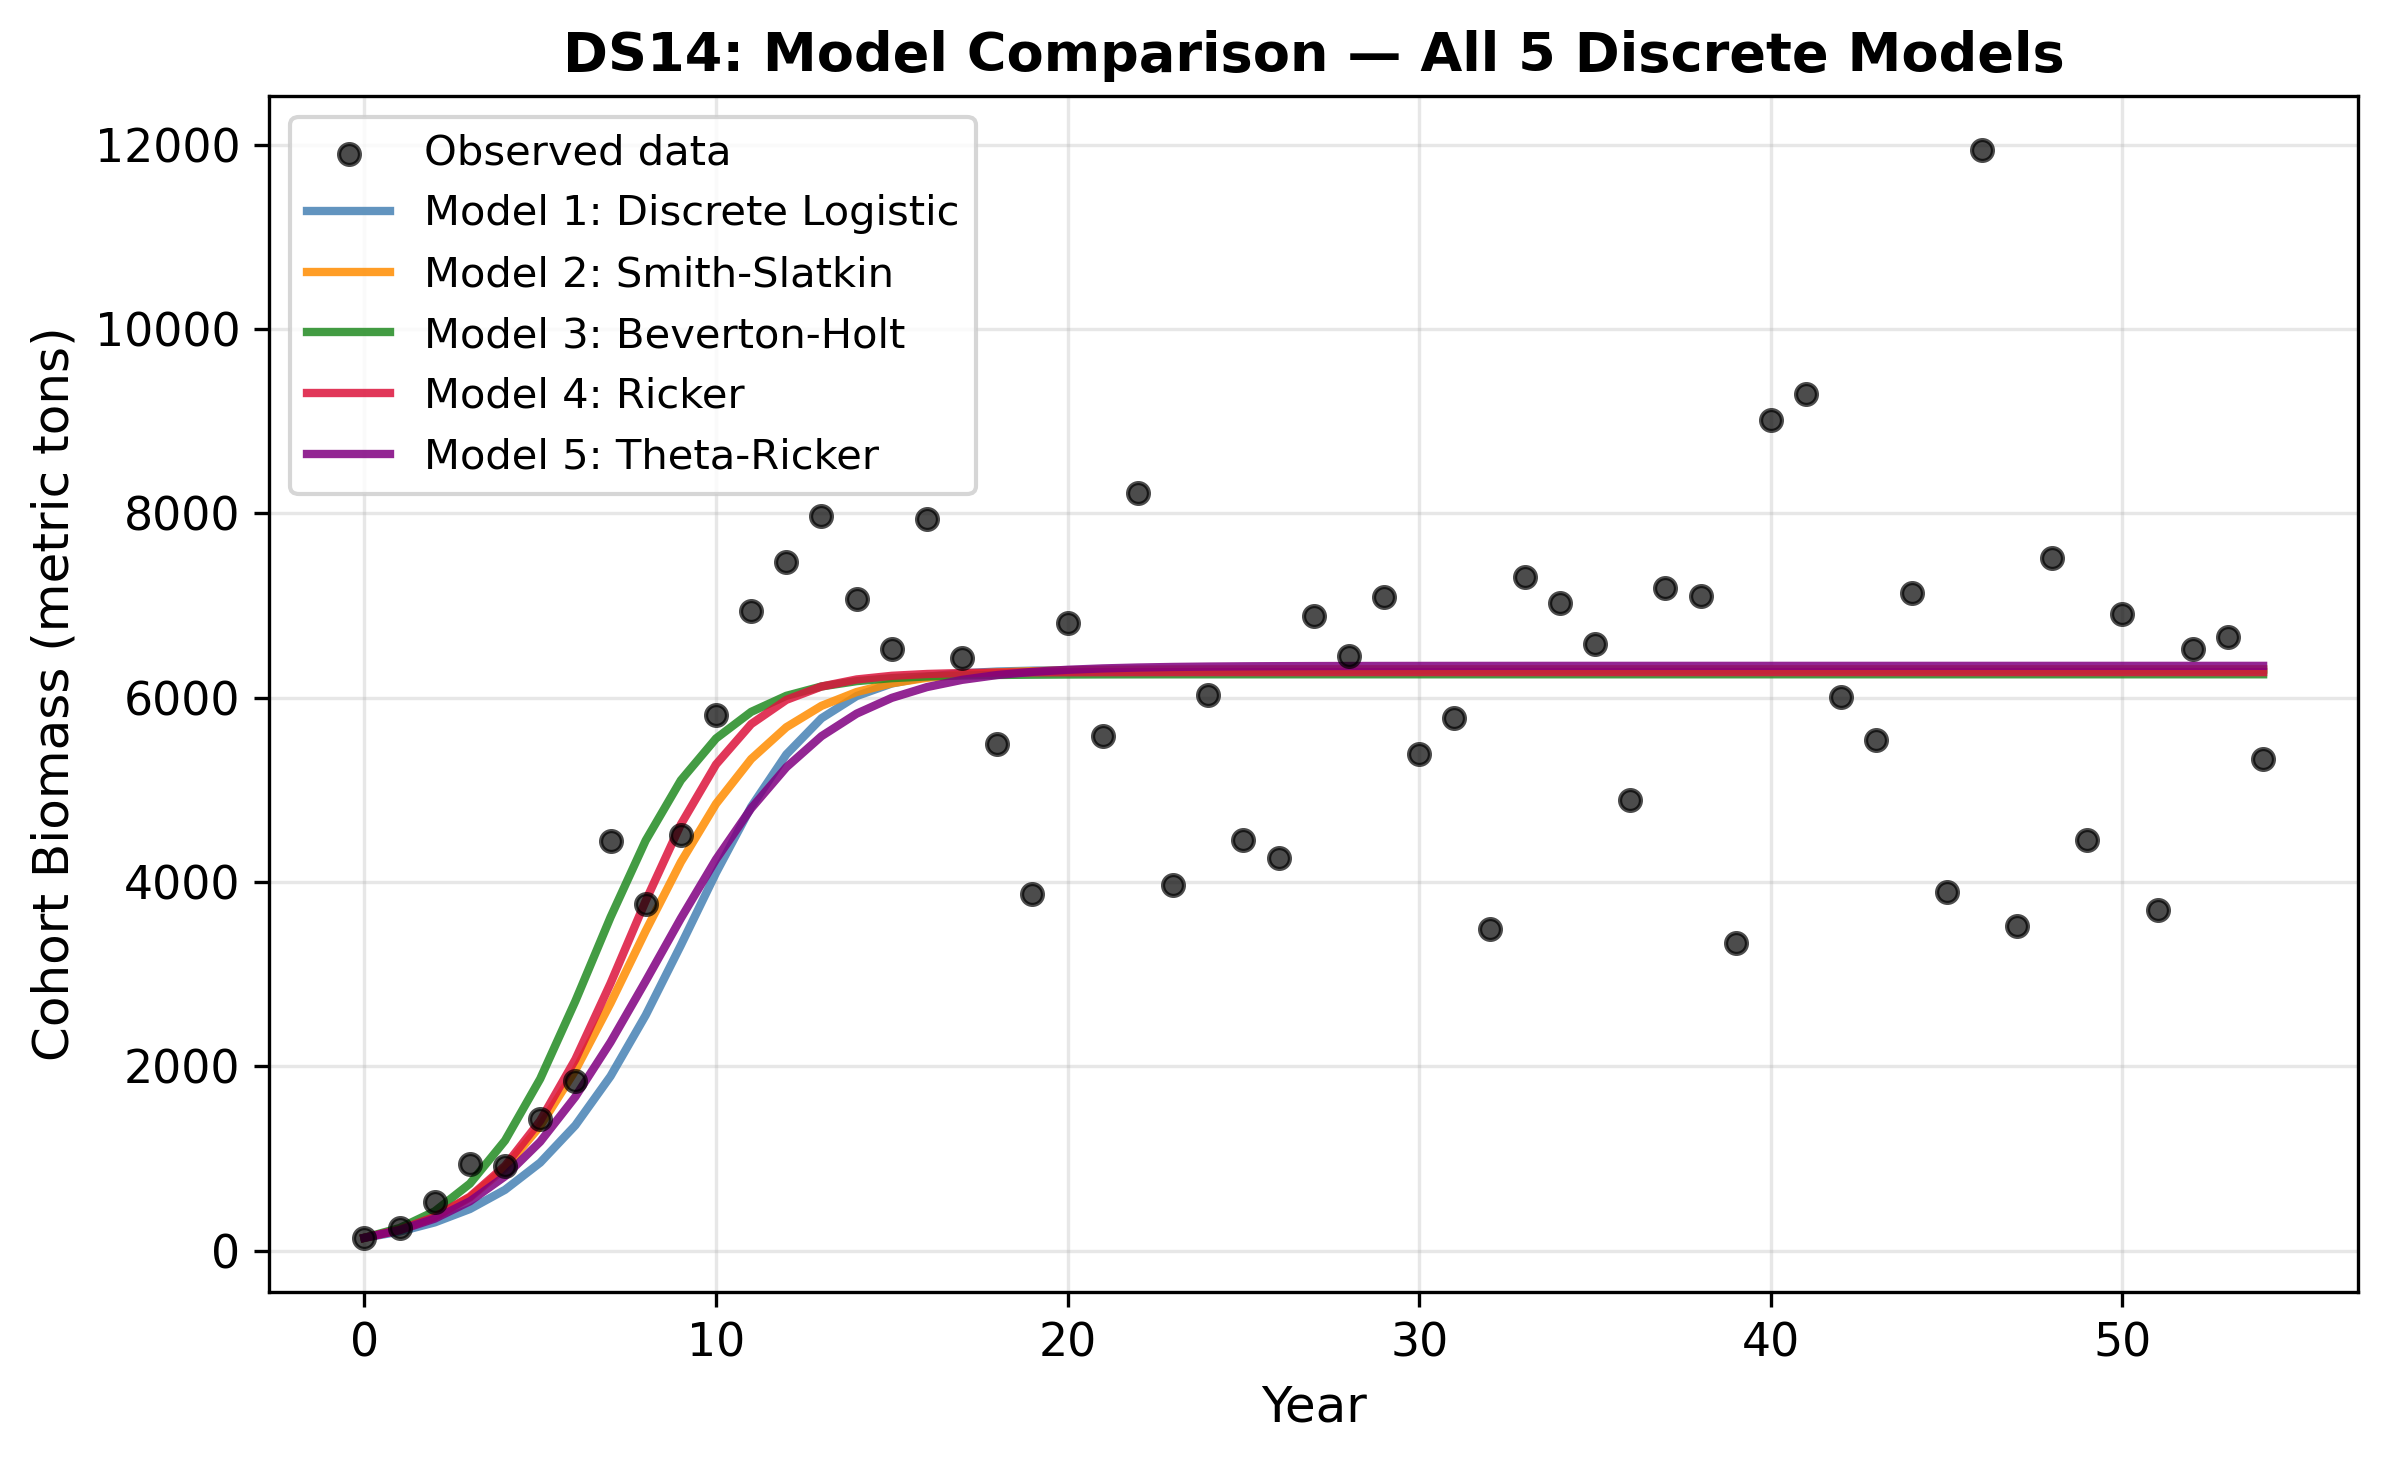

Saved: super_plot.png


In [6]:
# Figure 2: Super Plot - All 5 Models Overlaid

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# Plot observed data
ax.scatter(t_data, y_data, s=25, color='black', label='Observed data', zorder=5, alpha=0.7)

# Plot all 5 model fits
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
labels = [
    'Model 1: Discrete Logistic',
    'Model 2: Smith-Slatkin',
    'Model 3: Beverton-Holt',
    'Model 4: Ricker',
    'Model 5: Theta-Ricker'
]
predictions = [ypred_1, ypred_2, ypred_3, ypred_4, ypred_5]

for i, (pred, color, label) in enumerate(zip(predictions, colors, labels)):
    ax.plot(t_data, pred, color=color, lw=2, label=label, alpha=0.85)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cohort Biomass (metric tons)', fontsize=12)
ax.set_title('DS14: Model Comparison — All 5 Discrete Models', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('super_plot.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: super_plot.png')


---
## Step 4. Validate and Select


### Figure 4: Residual Plots

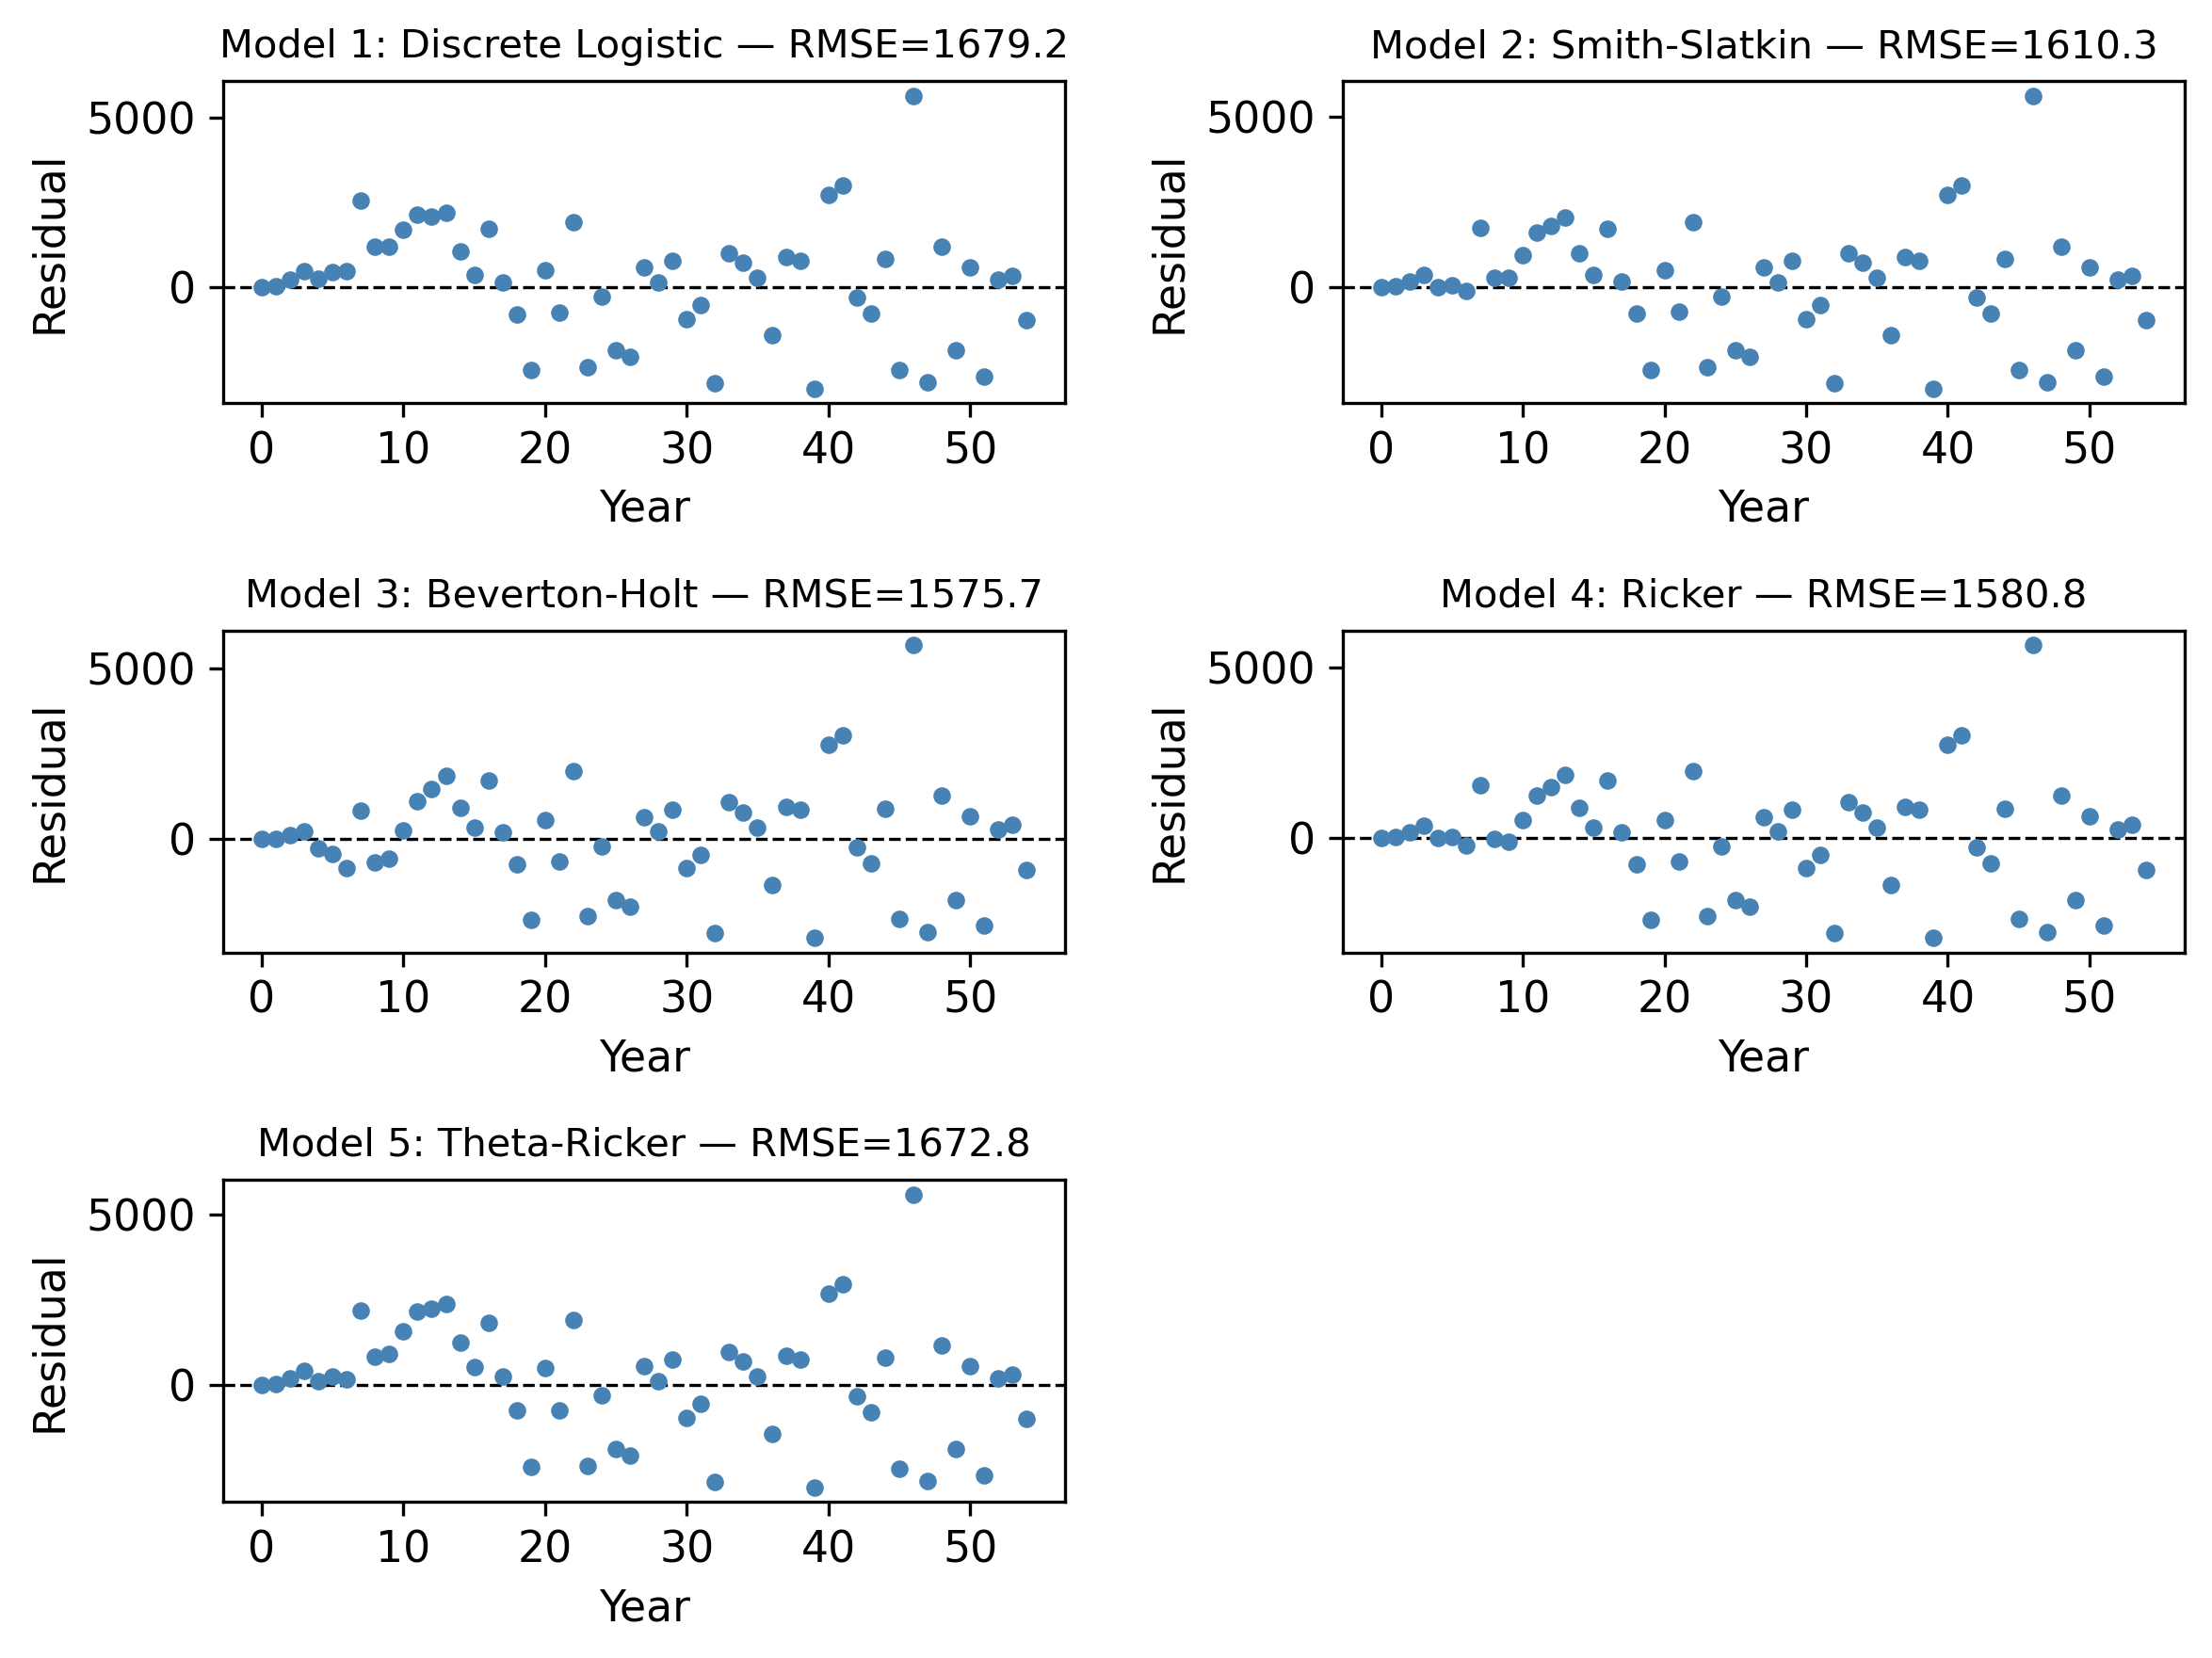

Saved: residuals_all_models.png


In [7]:
# Residuals for all five models (3x2 grid)
residuals = {
    'Model 1: Discrete Logistic': y_data - ypred_1,
    'Model 2: Smith-Slatkin': y_data - ypred_2,
    'Model 3: Beverton-Holt': y_data - ypred_3,
    'Model 4: Ricker': y_data - ypred_4,
    'Model 5: Theta-Ricker': y_data - ypred_5,
}

names = list(residuals.keys())
fig, axes = plt.subplots(3, 2, figsize=(FIG_WIDTH, FIG_HEIGHT * 1.2))
axes = axes.flatten()
for i, name in enumerate(names):
    ax = axes[i]
    res = residuals[name]
    ax.scatter(t_data, res, s=12, color='steelblue', zorder=5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    rmse = np.sqrt(np.mean(res**2))
    ax.set_title(f'{name} — RMSE={rmse:.1f}', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Residual')

# Hide the unused subplot if present
if len(axes) > len(names):
    for ax in axes[len(names):]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('residuals_all_models.png', bbox_inches='tight')
plt.show()
print('Saved: residuals_all_models.png')


### AICc values

$$
\mathrm{AIC} = n\ln\!\left(\frac{\mathrm{RSS}}{n}\right) + 2k,
\qquad
\mathrm{AIC}_c = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1},
\qquad
\Delta = \mathrm{AIC}_c^{(i)} - \min_j\,\mathrm{AIC}_c^{(j)} \ge 0
$$

$k=$ number of **fitted** parameters only.  Fixed parameters printed as numbers on your scenario card do **not** count.


In [8]:
k = 2  # Both fitted parameters for all models (r and K) except Beverton-Holt which has (lambda, a)

def compute_aicc(y_obs, y_hat, k, n):
    rss = np.sum((y_obs - y_hat)**2)
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
    return rss, aicc

# Compute for all 5 models
rss_1, aicc_1 = compute_aicc(y_data, ypred_1, k, n_obs)
rss_2, aicc_2 = compute_aicc(y_data, ypred_2, k, n_obs)
rss_3, aicc_3 = compute_aicc(y_data, ypred_3, k, n_obs)
rss_4, aicc_4 = compute_aicc(y_data, ypred_4, k, n_obs)
rss_5, aicc_5 = compute_aicc(y_data, ypred_5, k, n_obs)

best_aicc = min(aicc_1, aicc_2, aicc_3, aicc_4, aicc_5)

print(f'n = {n_obs},  k = {k}')
print()
print(f'{"Model":<26} {"RSS":>12}  {"AICc":>10}  {"Δ":>8}')
print('─' * 62)
print(f'{"Model 1: Discrete Logistic":<26} {rss_1:>12.2f}  {aicc_1:>10.2f}  {aicc_1 - best_aicc:>8.2f}')
print(f'{"Model 2: Smith-Slatkin":<26} {rss_2:>12.2f}  {aicc_2:>10.2f}  {aicc_2 - best_aicc:>8.2f}')
print(f'{"Model 3: Beverton-Holt":<26} {rss_3:>12.2f}  {aicc_3:>10.2f}  {aicc_3 - best_aicc:>8.2f}')
print(f'{"Model 4: Ricker":<26} {rss_4:>12.2f}  {aicc_4:>10.2f}  {aicc_4 - best_aicc:>8.2f}')
print(f'{"Model 5: Theta-Ricker":<26} {rss_5:>12.2f}  {aicc_5:>10.2f}  {aicc_5 - best_aicc:>8.2f}')

# Identify best model
models_aicc = {
    'Model 1: Discrete Logistic': aicc_1,
    'Model 2: Smith-Slatkin': aicc_2,
    'Model 3: Beverton-Holt': aicc_3,
    'Model 4: Ricker': aicc_4,
    'Model 5: Theta-Ricker': aicc_5
}
best_model = min(models_aicc, key=models_aicc.get)
print()
print(f'✓ BEST MODEL: {best_model}')


n = 55,  k = 2

Model                               RSS        AICc         Δ
──────────────────────────────────────────────────────────────
Model 1: Discrete Logistic 155084823.99      821.10      7.00
Model 2: Smith-Slatkin     142626489.67      816.49      2.39
Model 3: Beverton-Holt     136559247.62      814.10      0.00
Model 4: Ricker            137443815.42      814.46      0.36
Model 5: Theta-Ricker      153904465.72      820.68      6.58

✓ BEST MODEL: Model 3: Beverton-Holt


### Figure 5: Best-fitting model

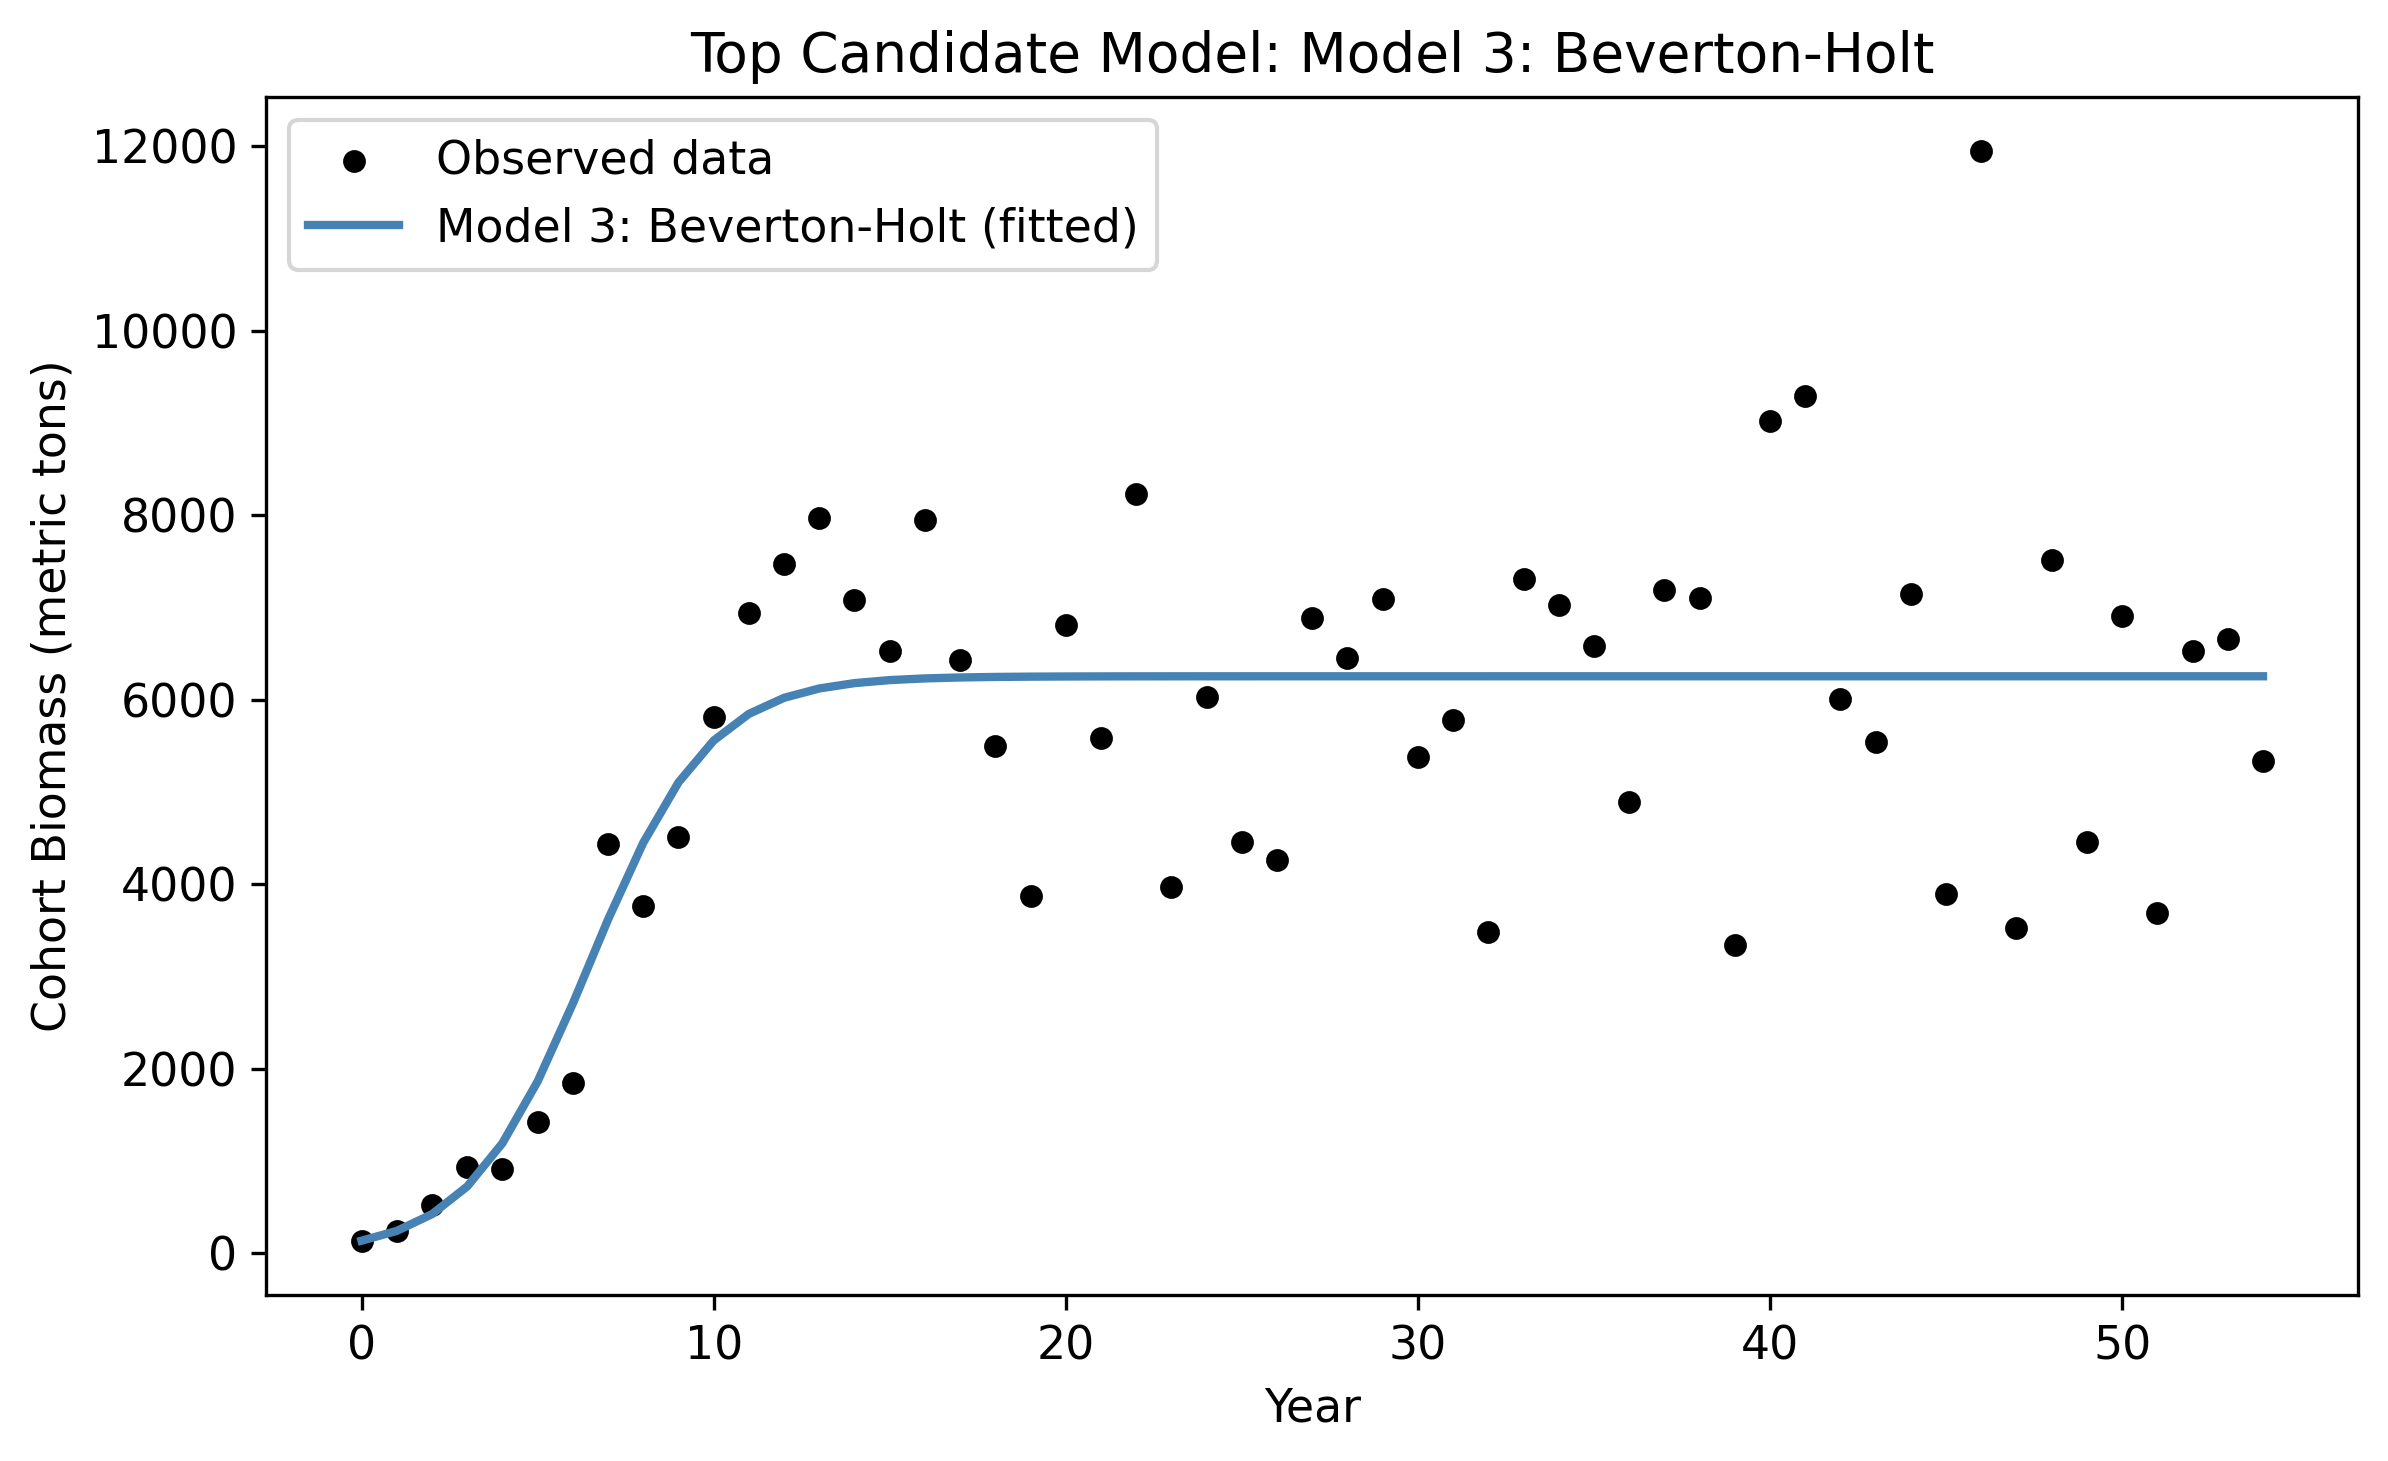

Saved: top_candidate_model.png


In [9]:
# Set these variables to the winning model (Beverton-Holt)
params_w = params_3
perr_w   = perr_3
ypred_w  = ypred_3
label_w  = 'Model 3: Beverton-Holt'

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax.scatter(t_data, y_data, s=20, color='black', label='Observed data')
ax.plot(t_data, ypred_w, color='steelblue', lw=2, label=f'{label_w} (fitted)')
ax.set_xlabel('Year')
ax.set_ylabel('Cohort Biomass (metric tons)')
ax.set_title(f'Top Candidate Model: {label_w}')
ax.legend()
plt.tight_layout()
plt.savefig('top_candidate_model.png', bbox_inches='tight')
plt.show()
print('Saved: top_candidate_model.png')


---
## Step 5. Interpret and Forecast

Parameter interpretation and the Limitations discussion belong entirely


### Step 5a: Parametric Bootstrap Forecast  *(bonus, +5 pts)*

The forecast simulates the winning model for 12 additional time steps
beyond the last observed data point.  The 95 % confidence interval is
built by drawing 1,000 alternative parameter vectors from the multivariate
normal distribution described by `params_w` and `cov_w`, propagating each
vector forward 12 steps, and taking the 2.5th and 97.5th percentiles at
each future step.

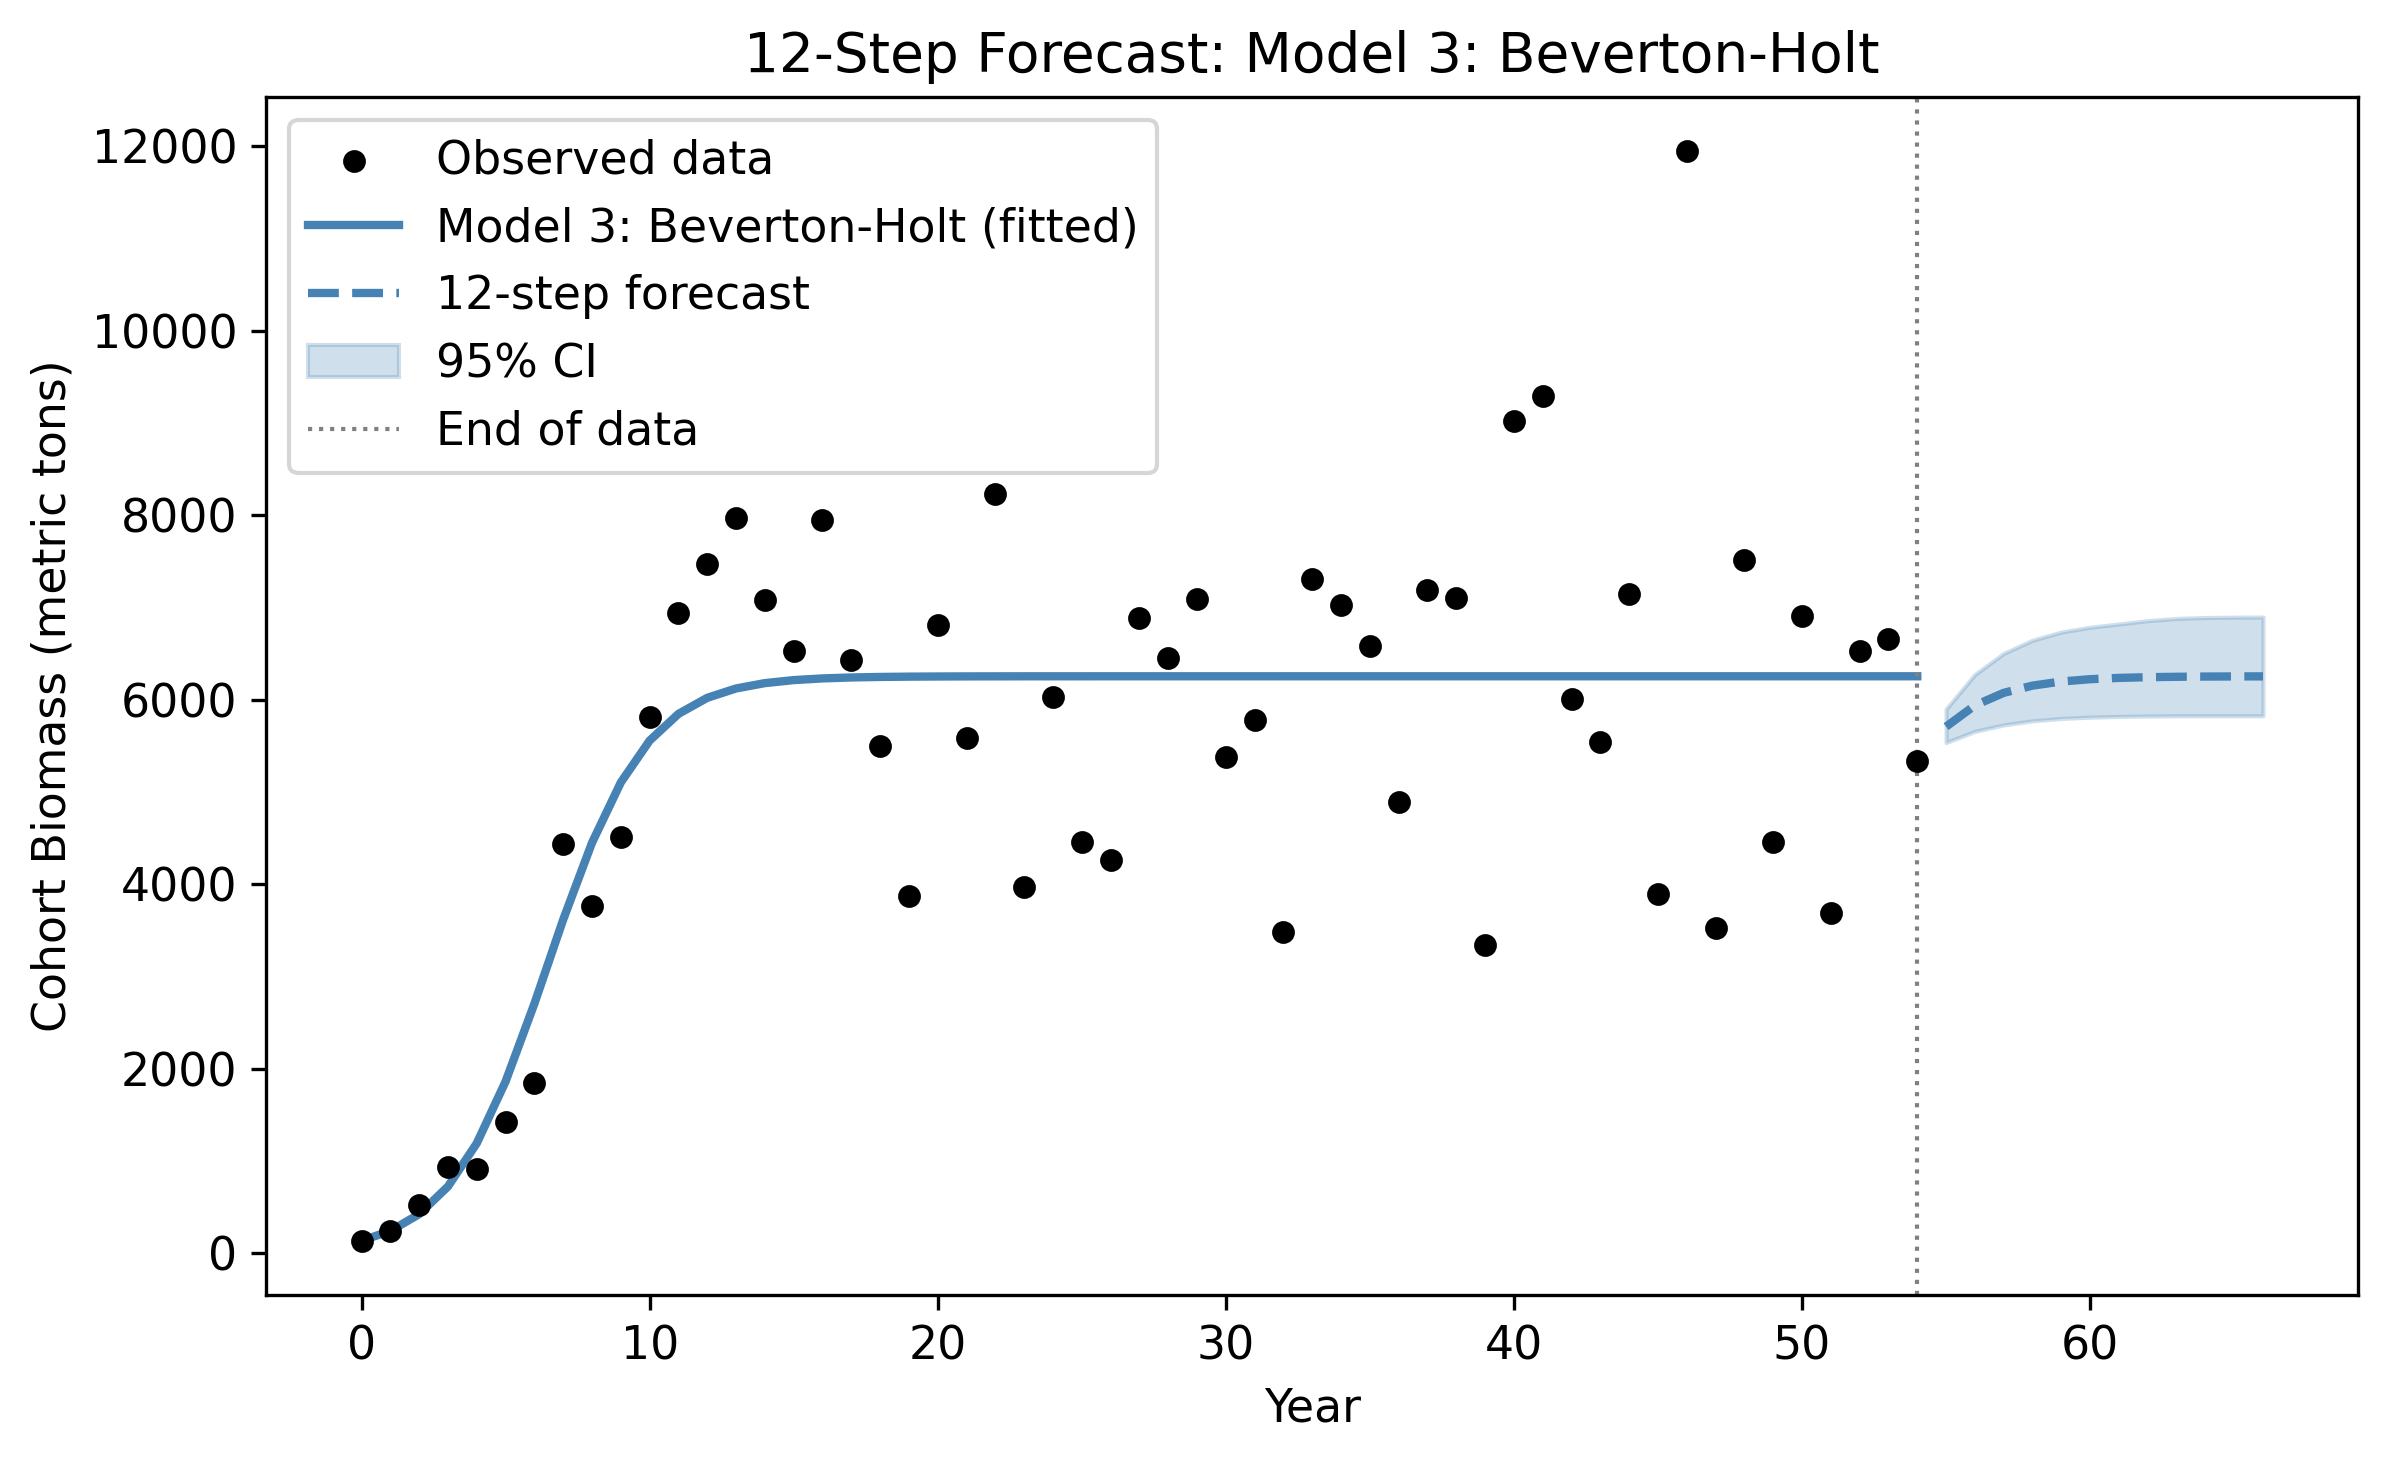

Forecast at step 12:
  Predicted          : 6252.7
  95% CI             : [5825.7,  6895.5]
  CI width           : 1069.8
  Observed data range: 11802
  Band / range       : 9.1 %
  (> 20–30% = poorly constrained forecast)


In [10]:
# Step 5: Forecasting with the winning model (simulate from last observed value)
winning_model = model3_beverton_holt  # Beverton-Holt is the winner
cov_w = cov_3  # covariance matrix for Beverton-Holt
params_w = params_3

N_FORECAST = 12
N_BOOTSTRAP = 1000

# Future time grid
if len(t_data) > 1:
    dt = t_data[1] - t_data[0]
else:
    dt = 1.0
t_future = t_data[-1] + dt * np.arange(1, N_FORECAST + 1)

# Helper: simulate Beverton-Holt forward from a given starting value
def beverton_holt_forecast(params, N_start, n_steps):
    lam, a = params
    out = np.empty(n_steps)
    Nprev = N_start
    for i in range(n_steps):
        Nnext = (lam * Nprev) / (1 + a * Nprev)
        out[i] = Nnext
        Nprev = Nnext
    return out

# Generate bootstrap samples of parameters
samples = rng.multivariate_normal(params_w, cov_w, size=N_BOOTSTRAP)

# Simulate each draw N_FORECAST forward starting from last observed value
boot = np.full((N_BOOTSTRAP, N_FORECAST), np.nan)
for i in range(N_BOOTSTRAP):
    try:
        boot[i] = beverton_holt_forecast(samples[i], y_data[-1], N_FORECAST)
    except Exception:
        boot[i] = np.nan

# 95% CI
lower = np.nanpercentile(boot, 2.5, axis=0)
upper = np.nanpercentile(boot, 97.5, axis=0)

# Fitted series across observed times (used for plotting the fitted curve)
y_fit = winning_model(t_data, *params_w)
# Deterministic forecast from fitted params starting at last observed
y_forecast = beverton_holt_forecast(params_w, y_data[-1], N_FORECAST)

# Figure: 12-Step Forecast with 95% CI
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.scatter(t_data, y_data, s=20, color='black', label='Observed data', zorder=5)
ax.plot(t_data, y_fit,  color='steelblue', lw=2, label=f'{label_w} (fitted)')
ax.plot(t_future, y_forecast, color='steelblue', lw=2, linestyle='--',
        label='12-step forecast')
ax.fill_between(t_future, lower, upper, color='steelblue', alpha=0.25,
                label='95% CI')
ax.axvline(t_data[-1], color='gray', lw=1, linestyle=':', label='End of data')

ax.set_xlabel('Year')
ax.set_ylabel('Cohort Biomass (metric tons)')
ax.set_title(f'12-Step Forecast: {label_w}')
ax.legend()
plt.tight_layout()
plt.savefig('step5_forecast.png', bbox_inches='tight')
plt.show()

# Summary statistics
obs_range  = y_data.max() - y_data.min()
band_width = upper[-1] - lower[-1]

print(f'Forecast at step 12:')
print(f'  Predicted          : {y_forecast[-1]:.5g}')
print(f'  95% CI             : [{lower[-1]:.5g},  {upper[-1]:.5g}]')
print(f'  CI width           : {band_width:.5g}')
print(f'  Observed data range: {obs_range:.5g}')
print(f'  Band / range       : {100 * band_width / obs_range:.1f} %')
print('  (> 20–30% = poorly constrained forecast)')


---
## Bonus: Holdout MSE  *(+5 pts)*

Each model is refit on the first 80% of time points (the **training** set).
Mean squared error is then computed on the withheld final 20% (the
**test** set, also called the holdout set because the model has never seen
those points). A model that overfits the training data will show a
noticeably higher holdout MSE than a model that generalises well.

**Important caveat for saturating models.** If your dataset is DS01–DS10
(continuous-time, monotone), the final 20% may contain the plateau region
that carries the most information about the carrying capacity *K*. In that
case, a high holdout MSE may reflect the absence of plateau data in the
training set, not overfitting (acknowledge this in your report if it
applies).

In [11]:
# Holdout split
n_train = int(0.8 * n_obs)
t_train = t_data[:n_train]
y_train = y_data[:n_train]
t_test = t_data[n_train:]
y_test = y_data[n_train:]

print(f'Training set : {n_train} points  '
      f'({100 * n_train / n_obs:.0f} %  of data)')
print(f'Test set     : {n_obs - n_train} points  '
      f'({100 * (n_obs - n_train) / n_obs:.0f} %  of data)')
print()

# Define model list and parameter seeds/bounds used above
model_list = [
    ('Model 1: Discrete Logistic', model1_discrete_logistic, p0_1, bounds_1),
    ('Model 2: Smith-Slatkin', model2_smith_slatkin, p0_2, bounds_2),
    ('Model 3: Beverton-Holt', model3_beverton_holt, p0_3, bounds_3),
    ('Model 4: Ricker', model4_ricker, p0_4, bounds_4),
    ('Model 5: Theta-Ricker', model5_theta_ricker, p0_5, bounds_5),
]

# Full-fit params fallback (in case train fit fails)
full_params = {
    'Model 1: Discrete Logistic': params_1,
    'Model 2: Smith-Slatkin': params_2,
    'Model 3: Beverton-Holt': params_3,
    'Model 4: Ricker': params_4,
    'Model 5: Theta-Ricker': params_5,
}

holdout_mse = {}
print(f'{"Model":<26} {"Holdout MSE":>14}')
print('─' * 42)
for name, func, p0, bounds in model_list:
    try:
        params_tr, cov_tr = curve_fit(func, t_train, y_train, p0=p0, bounds=bounds, maxfev=10000)
    except Exception:
        # fallback to full-data fit if training fit fails
        params_tr = full_params[name]
    # predict on test set
    y_pred_test = func(t_test, *params_tr)
    mse = np.mean((y_test - y_pred_test)**2)
    holdout_mse[name] = (params_tr, mse)
    print(f'{name:<26} {mse:14.3f}')

# Determine holdout winner (lowest MSE)
WINNING_MODEL = min(holdout_mse, key=lambda k: holdout_mse[k][1])
print() 
print(f'✓ HOLDOUT WINNER: {WINNING_MODEL} (MSE = {holdout_mse[WINNING_MODEL][1]:.3f})')


Training set : 44 points  (80 %  of data)
Test set     : 11 points  (20 %  of data)

Model                         Holdout MSE
──────────────────────────────────────────
Model 1: Discrete Logistic   29915476.265
Model 2: Smith-Slatkin       27226278.680
Model 3: Beverton-Holt       24919708.819
Model 4: Ricker              26663592.304
Model 5: Theta-Ricker        28561207.848

✓ HOLDOUT WINNER: Model 3: Beverton-Holt (MSE = 24919708.819)


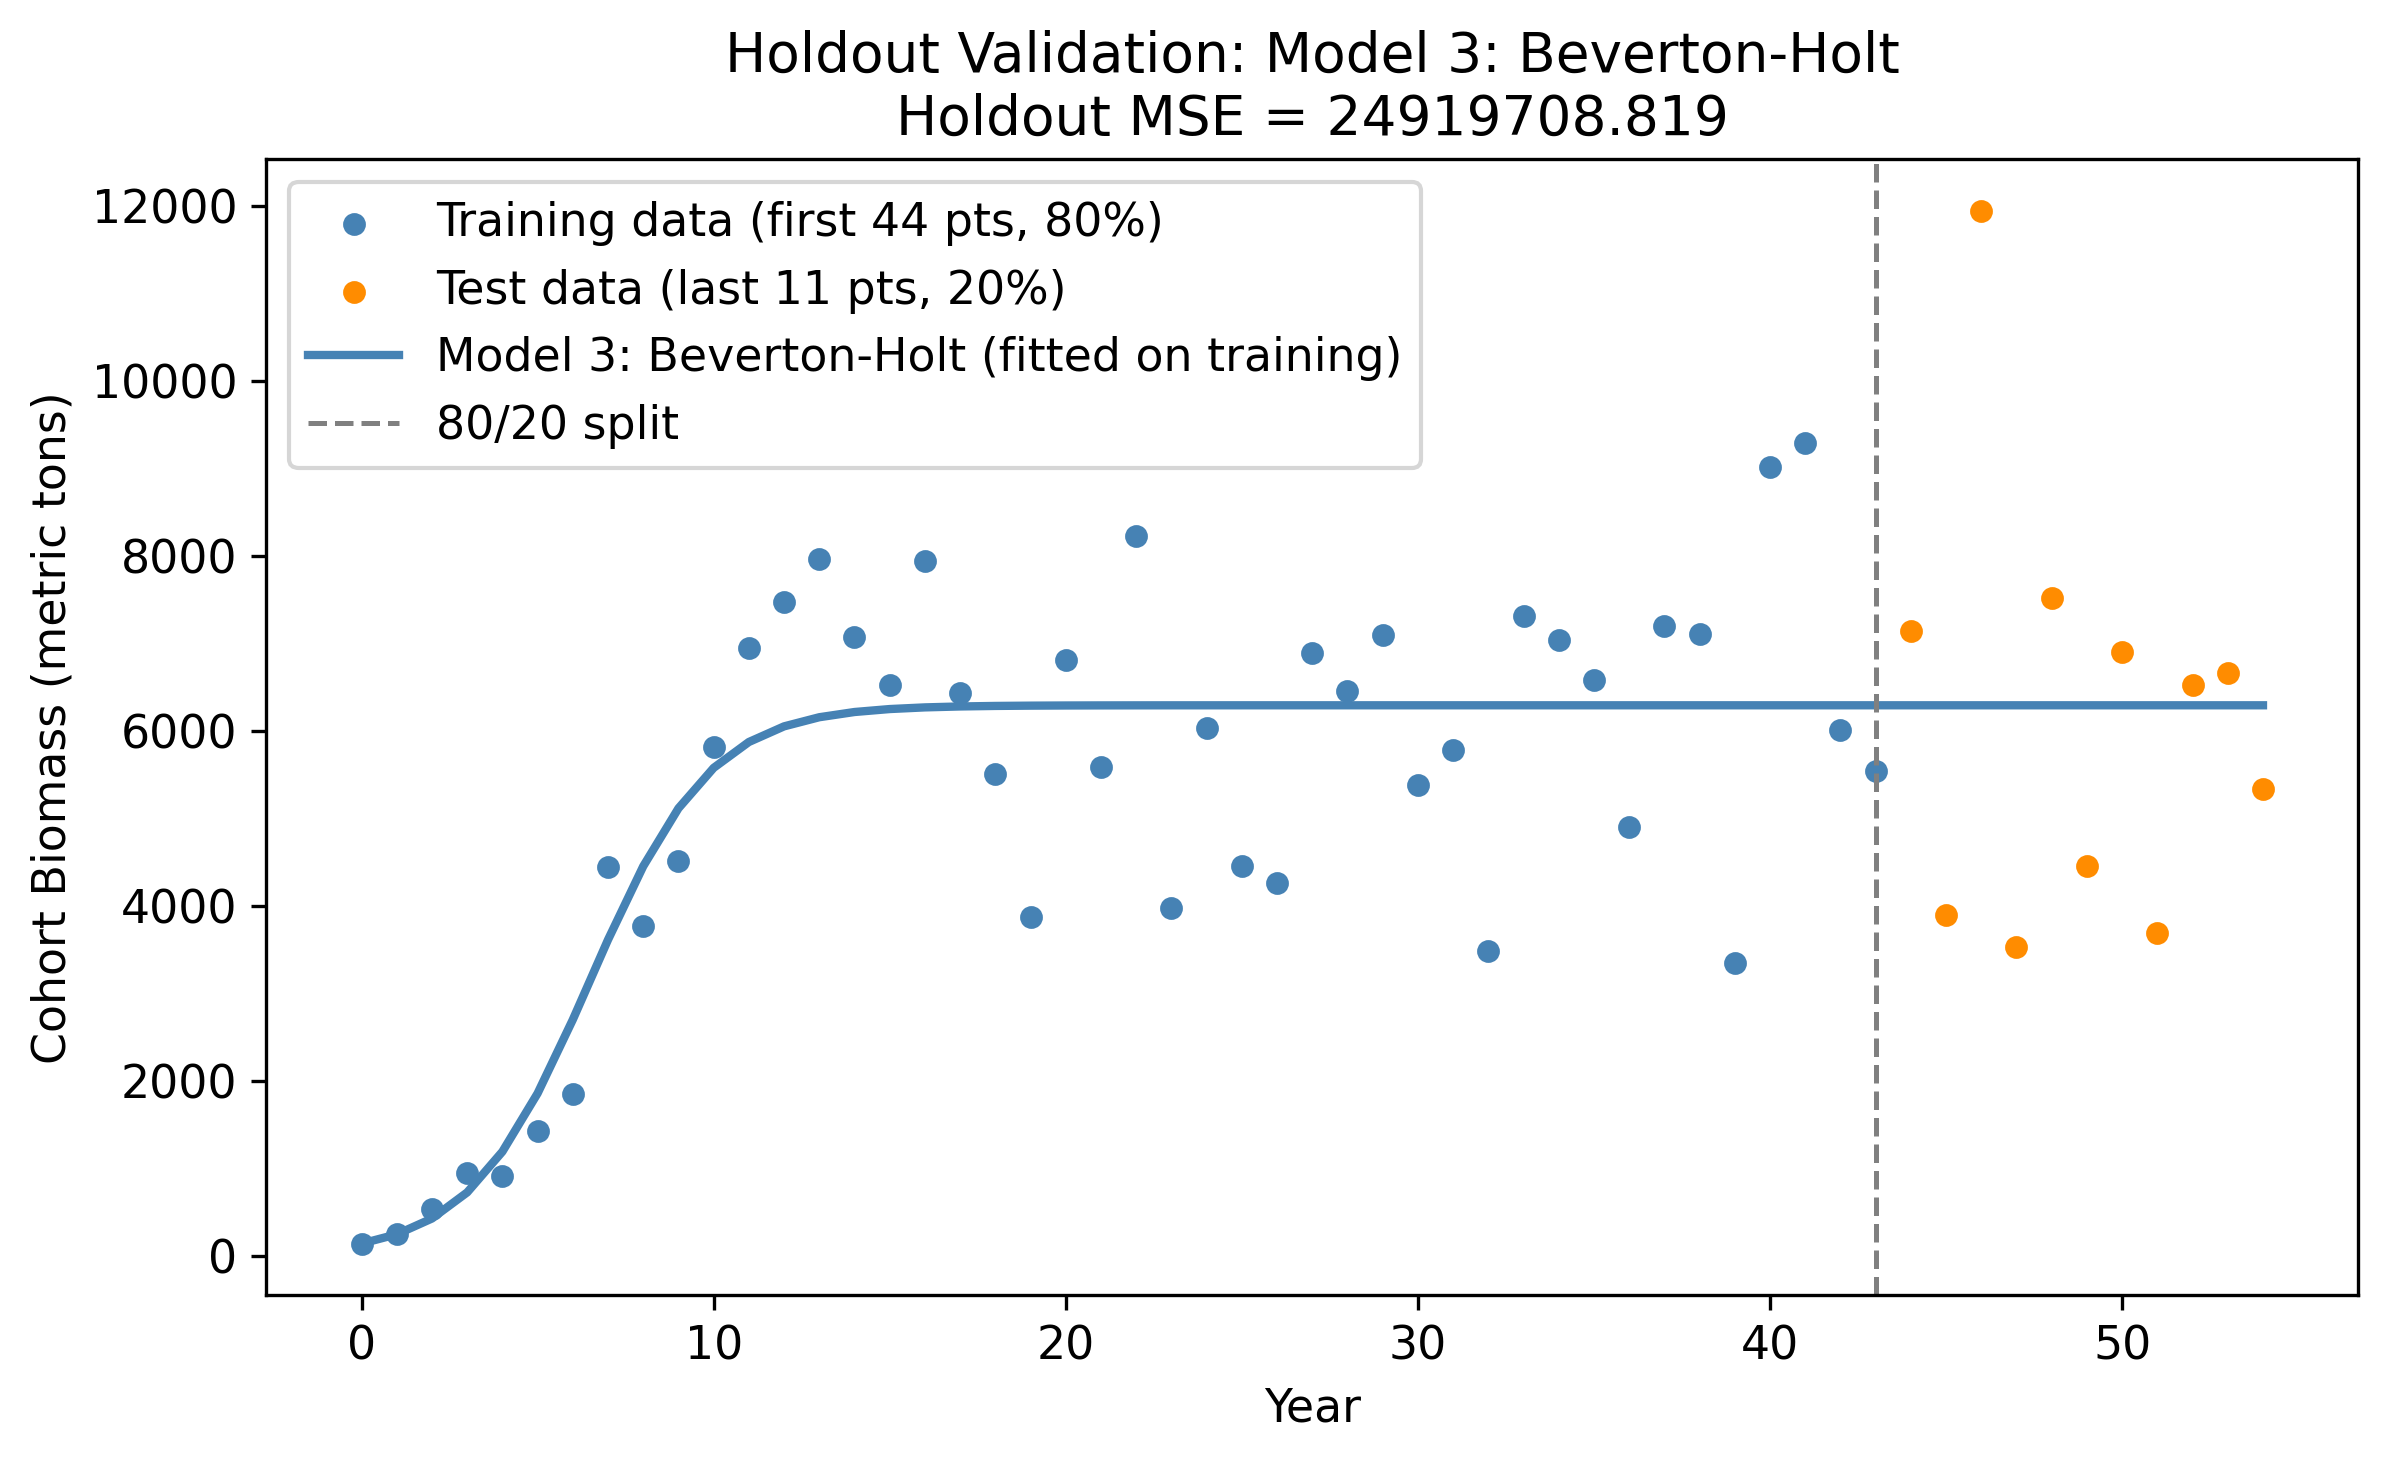

Saved: step4_holdout.png
Holdout MSE for Model 3: Beverton-Holt: 24919708.8194


In [12]:
# Holdout visualisation for the winning model
# Shows training data, test data, and the model curve fitted on training only,
# with a vertical dashed line at the 80/20 boundary.

# Map model names to functions
model_funcs = {
    'Model 1: Discrete Logistic': model1_discrete_logistic,
    'Model 2: Smith-Slatkin': model2_smith_slatkin,
    'Model 3: Beverton-Holt': model3_beverton_holt,
    'Model 4: Ricker': model4_ricker,
    'Model 5: Theta-Ricker': model5_theta_ricker,
}

params_tr_w, mse_w = holdout_mse[WINNING_MODEL]
winning_model_func = model_funcs[WINNING_MODEL]

# full series predicted using parameters fitted on training set
y_full_tr = winning_model_func(t_data, *params_tr_w)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax.scatter(t_train, y_train, s=20, color='steelblue',
            label=f'Training data (first {n_train} pts, 80%)')
ax.scatter(t_test,  y_test,  s=20, color='darkorange',
            label=f'Test data (last {n_obs - n_train} pts, 20%)',
            zorder=5)
ax.plot(t_data, y_full_tr, color='steelblue', lw=2.0,
        label=f'{WINNING_MODEL} (fitted on training)')
ax.axvline(t_data[n_train - 1], color='gray', lw=1.2,
            linestyle='--', label='80/20 split')
ax.set_xlabel('Year')
ax.set_ylabel('Cohort Biomass (metric tons)')
ax.set_title(f'Holdout Validation: {WINNING_MODEL}\nHoldout MSE = {mse_w:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('step4_holdout.png', bbox_inches='tight')
plt.show()
print('Saved: step4_holdout.png')
print(f'Holdout MSE for {WINNING_MODEL}: {mse_w:.4f}')
